<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologías Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Línea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibagué-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingeniería</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingeniería de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab — Clasificador Base con PyTorch</div>

# Notebook 1: Entrenamiento Base del Clasificador de Aves

## 1. Introducción

En este notebook entrenamos un clasificador de aves usando **Transfer Learning con MobileNetV2** y PyTorch — sin ninguna técnica de optimización avanzada.

El objetivo académico es **observar el comportamiento natural del modelo**:
cómo aprende, cuándo empieza a fallar y qué señales nos dejan las curvas de pérdida y precisión.

> 🎯 **Esta es la línea base.** En notebooks posteriores aplicaremos técnicas como fine-tuning,
> early stopping y cambio de backbone para mejorar estos resultados y comparar el impacto de cada una.

### ¿Qué haremos aquí?
1. Cargar el dataset de aves con aumentaciones básicas
2. Construir el modelo: MobileNetV3-Large con el **backbone completamente congelado**
3. Entrenar **solo la cabeza clasificadora** por N épocas sin parar antes de tiempo
4. Visualizar las curvas de entrenamiento para diagnosticar el comportamiento


## 2. Preparación del Entorno

In [1]:
import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json, time
from datetime import datetime

print(f"PyTorch:         {torch.__version__}")
print(f"Torchvision:     {torchvision.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo:     {device}")


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


PyTorch:         2.11.0+cu130
Torchvision:     0.26.0+cu130
CUDA disponible: False
Dispositivo:     cpu


## 3. Hiperparámetros

Definimos los parámetros de entrenamiento. Intencionalemente usamos valores que pueden
mostrar problemas como overfitting o convergencia lenta — así tendremos algo concreto
que mejorar en los siguientes notebooks.

| Parámetro | Valor | Por qué este valor |
|-----------|-------|--------------------|
| `IMAGE_SIZE` | 224 | Estándar de ImageNet, necesario para el backbone |
| `BATCH_SIZE` | 32 | Valor común, sin ajuste especial |
| `NUM_EPOCHS` | 20 | Suficientes para ver el comportamiento completo |
| `LR` | 1e-3 | Learning rate inicial, puede ser alto para algunas clases |


In [4]:
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-3

# Rutas del dataset (ajustar según tu estructura de carpetas)
DATASET_ROOT = Path("../data/split")
TRAIN_DIR    = DATASET_ROOT / "train"
VAL_DIR      = DATASET_ROOT / "val"
OUTPUT_DIR   = Path("../src/models/checkpoints")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuración cargada:")
print(f"  Épocas:     {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  LR:         {LR}")
print(f"  Dataset:    {DATASET_ROOT}")


Configuración cargada:
  Épocas:     20
  Batch size: 32
  LR:         0.001
  Dataset:    ../data/split


## 4. Transformaciones y Carga de Datos

Aplicamos aumentaciones básicas al conjunto de entrenamiento para que el modelo no memorice
las imágenes tal cual. En validación usamos las imágenes sin modificar.

### ¿Por qué normalizar con estos valores?

`[0.485, 0.456, 0.406]` y `[0.229, 0.224, 0.225]` son la media y desviación estándar
de ImageNet. El backbone fue entrenado esperando esos valores — si no normalizamos igual,
las activaciones internas del modelo no tendrán sentido.


In [5]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Cargar datasets
train_ds = ImageFolder(root=str(TRAIN_DIR), transform=TRAIN_TRANSFORM)
val_ds   = ImageFolder(root=str(VAL_DIR),   transform=EVAL_TRANSFORM)

classes     = train_ds.classes
num_classes = len(classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Especies ({num_classes}):")
for i, c in enumerate(classes):
    print(f"  [{i:02d}] {c}")
print(f"\nImágenes — Train: {len(train_ds)} | Val: {len(val_ds)}")


Especies (16):
  [00] ardea-alba
  [01] atlapetes-latinuchus
  [02] butorides-striata
  [03] chlorochrysa-nitidissima
  [04] colibri-coruscans
  [05] common-gallinule
  [06] metallura-tyrianthina
  [07] momotus-aequatorialis
  [08] phimosus-infuscatus
  [09] piaya-cayana
  [10] pitangus-sulphuratus
  [11] ramphastos-ambiguus
  [12] sicalis-flaveola
  [13] thraupis-episcopus
  [14] turdus-fuscater
  [15] zenaida-auriculata

Imágenes — Train: 1046 | Val: 204


## 5. Construcción del Modelo

Usamos **MobileNetV3-Large** preentrenado en ImageNet. El backbone queda **completamente
congelado** — sus pesos no cambian durante el entrenamiento. Solo entrenamos la
capa de clasificación final, que reemplazamos para adaptarla a nuestras especies.

```
MobileNetV3-Large (congelado)
        ↓
  [features extraídas de ImageNet]
        ↓
  Linear(960 → num_classes)   ← solo esto aprende
```

> En el siguiente notebook veremos qué pasa cuando descongelamos el backbone (fine-tuning).


In [7]:
# Cargar MobileNetV3-Small preentrenado
backbone = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
)

# Congelar TODOS los parámetros del backbone
for param in backbone.parameters():
    param.requires_grad = False

# Reemplazar solo la última capa lineal del clasificador
in_features = backbone.classifier[3].in_features
backbone.classifier[3] = nn.Linear(in_features, num_classes)
# La nueva capa SÍ tiene requires_grad=True por defecto

model = backbone.to(device)

# Verificar qué parámetros se entrenan
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales:     {total:,}")
print(f"Parámetros entrenables: {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"\nSolo la capa final aprende — el backbone actúa como extractor fijo.")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/walter/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████████████████████████████████████████████████████████████████████████| 9.83M/9.83M [00:01<00:00, 9.24MB/s]


Parámetros totales:     1,534,256
Parámetros entrenables: 16,400  (1.07%)

Solo la capa final aprende — el backbone actúa como extractor fijo.


## 6. Entrenamiento

Entrenamos por `NUM_EPOCHS` épocas sin interrumpir, sin reducir el learning rate y
sin ningún criterio de parada anticipada. Queremos ver la curva completa.

Cada época registra:
- `train_loss` / `train_acc`: rendimiento sobre datos de entrenamiento
- `val_loss` / `val_acc`: rendimiento sobre datos de validación (nunca vistos en entrenamiento)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)

history = []

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total

print("Iniciando entrenamiento base...")
print(f"{'Época':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}  {'Tiempo':>7}")
print("-" * 60)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, None)

    elapsed = time.time() - t0

    record = {
        "epoch":      epoch,
        "train_loss": round(train_loss, 4),
        "train_acc":  round(train_acc,  4),
        "val_loss":   round(val_loss,   4),
        "val_acc":    round(val_acc,    4),
        "elapsed_s":  round(elapsed,    1),
    }
    history.append(record)

    marker = " ★" if val_acc > best_val_acc else ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc

    print(f"{epoch:>6}  {train_loss:>10.4f}  {train_acc:>9.4f}  "
          f"{val_loss:>9.4f}  {val_acc:>8.4f}  {elapsed:>6.1f}s{marker}")

print(f"\n✔ Entrenamiento completo. Mejor val_acc = {best_val_acc:.4f}")

Iniciando entrenamiento base...
 Época  Train Loss  Train Acc   Val Loss   Val Acc   Tiempo
------------------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1      2.1206     0.5191     1.1404    0.7500    23.5s ★
     2      1.1774     0.8442     0.6613    0.8775    17.3s ★
     3      0.7953     0.8920     0.4936    0.9118    19.0s ★
     4      0.5937     0.9092     0.4220    0.9265    27.7s ★
     5      0.4888     0.9302     0.3868    0.9314    24.0s ★
     6      0.4088     0.9465     0.3607    0.9461    17.8s ★
     7      0.3509     0.9474     0.3385    0.9510    18.1s ★
     8      0.3130     0.9637     0.3288    0.9461    19.0s
     9      0.2844     0.9570     0.3134    0.9510    17.6s
    10      0.2542     0.9665     0.3001    0.9461    17.6s
    11      0.2461     0.9618     0.2934    0.9461    17.3s
    12      0.2166     0.9675     0.2861    0.9461    17.1s
    13      0.1970     0.9713     0.2788    0.9363    17.6s
    14      0.1866     0.9761     0.2729    0.9363    17.9s
    15      0.1668     0.9780     0.2663    0.9412    18.0s
    16      0.1705     0.9809     0.2616    0.9510    18.2s
    17      0.1466     0.9

## 7. Guardado del Historial

In [11]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = Path("../logs/training")
log_dir.mkdir(parents=True, exist_ok=True)

history_file = log_dir / f"{ts}_mobilenet_v3_small_base_history.json"
history_file.write_text(json.dumps(history, indent=2))

# Guardar también el checkpoint del mejor modelo
torch.save({
    "epoch":             NUM_EPOCHS,
    "phase":             "base",
    "model_name":        "mobilenet_v3_small",
    "model_state_dict":  model.state_dict(),
    "best_val_acc":      best_val_acc,
    "classes":           classes,
    "class_to_idx":      train_ds.class_to_idx,
}, OUTPUT_DIR / "mobilenet_v3_small_base.pth")

print(f"Historial  → {history_file}")
print(f"Checkpoint → {OUTPUT_DIR / 'mobilenet_v3_small_base.pth'}")


Historial  → ../logs/training/20260405_184106_mobilenet_v3_small_base_history.json
Checkpoint → ../src/models/checkpoints/mobilenet_v3_small_base.pth


## 8. Visualización de las Curvas de Entrenamiento

Las gráficas son la herramienta de diagnóstico principal. Miramos dos cosas:

- **Accuracy**: ¿Suben ambas curvas? ¿Se separan (train alta, val baja)?
- **Loss**: ¿Bajan ambas? ¿Sube la val_loss mientras la train_loss sigue bajando?


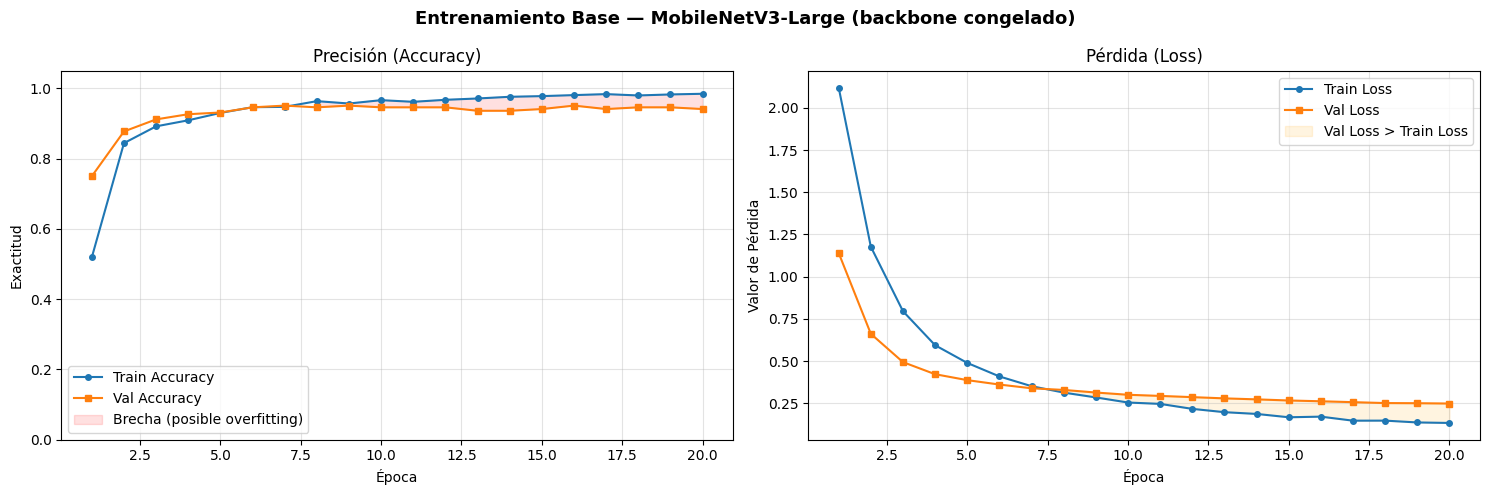

Gráfica guardada.


In [12]:
epochs      = [r["epoch"]      for r in history]
train_accs  = [r["train_acc"]  for r in history]
val_accs    = [r["val_acc"]    for r in history]
train_losses= [r["train_loss"] for r in history]
val_losses  = [r["val_loss"]   for r in history]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Entrenamiento Base — MobileNetV3-Large (backbone congelado)",
             fontsize=13, fontweight='bold')

# Accuracy
ax = axes[0]
ax.plot(epochs, train_accs,  marker='o', markersize=4, label='Train Accuracy')
ax.plot(epochs, val_accs,    marker='s', markersize=4, label='Val Accuracy')
ax.fill_between(epochs, train_accs, val_accs,
                where=[t > v for t, v in zip(train_accs, val_accs)],
                alpha=0.12, color='red', label='Brecha (posible overfitting)')
ax.set_title("Precisión (Accuracy)")
ax.set_xlabel("Época")
ax.set_ylabel("Exactitud")
ax.legend()
ax.grid(True, alpha=0.35)
ax.set_ylim(0, 1.05)

# Loss
ax = axes[1]
ax.plot(epochs, train_losses, marker='o', markersize=4, label='Train Loss')
ax.plot(epochs, val_losses,   marker='s', markersize=4, label='Val Loss')
ax.fill_between(epochs, val_losses, train_losses,
                where=[v > t for v, t in zip(val_losses, train_losses)],
                alpha=0.12, color='orange', label='Val Loss > Train Loss')
ax.set_title("Pérdida (Loss)")
ax.set_xlabel("Época")
ax.set_ylabel("Valor de Pérdida")
ax.legend()
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(log_dir / f"{ts}_curvas_base.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")


## 9. Diagnóstico del Comportamiento

Esta celda analiza las curvas automáticamente y señala los patrones más importantes
que deberías observar y anotar para el informe académico.


In [14]:
# ── Indicadores de diagnóstico ───────────────────────────────────
last     = history[-1]
best     = max(history, key=lambda r: r["val_acc"])
midpoint = history[NUM_EPOCHS // 2]

gap_acc_final  = round(last["train_acc"]  - last["val_acc"],  4)
gap_loss_final = round(last["val_loss"]   - last["train_loss"], 4)

# ¿Val loss subiendo en la segunda mitad?
segunda_mitad = history[NUM_EPOCHS // 2:]
val_loss_trend = segunda_mitad[-1]["val_loss"] - segunda_mitad[0]["val_loss"]

print("=" * 58)
print("  DIAGNÓSTICO DEL ENTRENAMIENTO BASE")
print("=" * 58)
print(f"  Mejor val_acc          : {best['val_acc']:.4f}  (época {best['epoch']})")
print(f"  Val_acc final          : {last['val_acc']:.4f}")
print(f"  Train_acc final        : {last['train_acc']:.4f}")
print(f"  Brecha train-val acc   : {gap_acc_final:+.4f}")
print(f"  Val_loss trend (2a mit): {val_loss_trend:+.4f}")
print()

# Señales de overfitting
if gap_acc_final > 0.10:
    print("⚠️  OVERFITTING detectado: train_acc >> val_acc")
    print("    → Técnicas a aplicar en el siguiente notebook:")
    print("      - Dropout más alto")
    print("      - Fine-tuning con LR bajo")
    print("      - Early stopping")
elif gap_acc_final < 0.02 and last["val_acc"] < 0.60:
    print("⚠️  UNDERFITTING: ambas precisiones son bajas")
    print("    → Técnicas a aplicar:")
    print("      - Más épocas")
    print("      - Descongelar backbone (fine-tuning)")
    print("      - Backbone más potente (EfficientNet)")
else:
    print("✅  Curvas equilibradas — buen punto de partida")

if val_loss_trend > 0.05:
    print("⚠️  Val_loss SUBE en la segunda mitad → el modelo empieza a memorizar")
    print(f"    El punto óptimo fue la época {best['epoch']}")
    print("    → Early stopping habría detenido aquí el entrenamiento")

print("=" * 58)


  DIAGNÓSTICO DEL ENTRENAMIENTO BASE
  Mejor val_acc          : 0.9510  (época 7)
  Val_acc final          : 0.9412
  Train_acc final        : 0.9847
  Brecha train-val acc   : +0.0435
  Val_loss trend (2a mit): -0.0452

✅  Curvas equilibradas — buen punto de partida


## 10. Tabla de Seguimiento Académico

Registra aquí los resultados de cada notebook a medida que avanzas.
La fila **N0 — Base** se completa automáticamente con la celda de abajo.

| # | Técnica aplicada | Val Acc | Train Acc | Gap (train-val) | Épocas | Observación |
|---|-----------------|---------|-----------|-----------------|--------|-------------|
| **N0 — Base** | Backbone congelado, sin ajustes | 0.9412 | 0.9847 | +0.0435 | 20 | Línea base |
| **N1 — Dropout** | + Dropout 50% | — | — | — | 20 | ¿Redujo el gap? |
| **N2 — Early Stopping** | + Early Stop (sin LR Decay) | — | — | — | ? | ¿Cuándo paró? |
| **N3 — LR Decay** | + ReduceLROnPlateau (sin ES) | — | — | — | 20 | ¿Curvas más suaves? |
| **N4 — ES + LR Decay** | + Ambas juntas | — | — | — | ? | ¿Mejor combinación? |
| **N5 — Todas** | + Checkpoints | — | — | — | ? | Mejor modelo guardado |

**Rutas de checkpoints:**
- Modelo base → `src/models/checkpoints/base/mobilenet_v3_small_base.pth`
- Mejor modelo pro → `src/models/checkpoints/pro/best.pth`
- Último modelo pro → `src/models/checkpoints/pro/last.pth`

> Ejecuta la celda siguiente para ver los valores del N0 que debes copiar en la primera fila.


In [15]:
# ── Valores del N0 listos para copiar en la tabla ────────────────
if 'history' in dir() and history:
    last  = history[-1]
    best  = max(history, key=lambda r: r["val_acc"])
    gap   = last["train_acc"] - last["val_acc"]

    print("=" * 52)
    print("  VALORES PARA LA TABLA — N0 BASE")
    print("=" * 52)
    print(f"  Val Acc  (mejor epoca)  : {best['val_acc']:.4f}")
    print(f"  Val Acc  (ultima epoca) : {last['val_acc']:.4f}")
    print(f"  Train Acc (ultima epoca): {last['train_acc']:.4f}")
    print(f"  Gap train-val           : {gap:+.4f}")
    print(f"  Epocas ejecutadas       : {last['epoch']}")
    print("=" * 52)
    print()
    print("  Copia estos valores en la fila N0 de la tabla de arriba.")
    print("  Luego ejecuta 05_training_pro.ipynb para los niveles N1-N4.")
else:
    print("[!] Ejecuta primero las celdas de entrenamiento (seccion 6).")


  VALORES PARA LA TABLA — N0 BASE
  Val Acc  (mejor epoca)  : 0.9510
  Val Acc  (ultima epoca) : 0.9412
  Train Acc (ultima epoca): 0.9847
  Gap train-val           : +0.0435
  Epocas ejecutadas       : 20

  Copia estos valores en la fila N0 de la tabla de arriba.
  Luego ejecuta 05_training_pro.ipynb para los niveles N1-N4.
